In [12]:
from google import genai
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

if os.environ['GEMINI_API_KEY']:
    print("key is the present")

else:
    print("key is not present or invalid")    


key is the present


In [13]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
response = llm.invoke("Explain RAG in one short sentence").content

In [14]:
from typing import TypedDict,List,Annotated
from operator import add

class graph_schema(TypedDict):
    message_manual:str
    # using reducer in langchain
    message_auto:Annotated[list,add]

In [15]:
from langchain_core.messages import AIMessage, HumanMessage

# 1. CREATE POST NODE
def create_post(state: graph_schema) -> dict:
    # --- MANUAL HISTORY ---
    message_manual_list = state['message_manual'] # Purani list uthai
    response_manual_text = llm.invoke(message_manual_list).content # LLM se string text liya
    response_manual_ai = AIMessage(content=response_manual_text) # AI box banaya
    
    # SAHI TARIKA: List + List ko add kiya
    updated_manual = message_manual_list + [response_manual_ai]

    # --- AUTO HISTORY ---
    message_auto_list = state['message_auto'] 
    response_auto_text = llm.invoke(message_auto_list).content 
    response_auto_ai = AIMessage(content=response_auto_text) 

    # FIXED: Return only the updates inside a pure dictionary
    return {
        "message_manual": updated_manual,
        "message_auto": [response_auto_ai] 
    }


# 2. CURATE POST NODE
def curate_post(state: graph_schema) -> dict:
    # --- MANUAL HISTORY ---
    message_manual_list = state['message_manual'] 
    response_manual_text = llm.invoke(message_manual_list).content 
    response_manual_ai = AIMessage(content=response_manual_text) 
    
    # SAHI TARIKA: List + List ko add kiya
    updated_manual = message_manual_list + [response_manual_ai]

    # --- AUTO HISTORY ---
    message_auto_list = state['message_auto'] 
    response_auto_text = llm.invoke(message_auto_list).content 
    response_auto_ai = AIMessage(content=response_auto_text) 

    # FIXED: Return only the updates inside a pure dictionary
    return {
        "message_manual": updated_manual,
        "message_auto": [response_auto_ai] 
    }
    

In [16]:

from langgraph.graph import StateGraph, START,END

graph = StateGraph(graph_schema)

# add node
graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

# add edge
graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

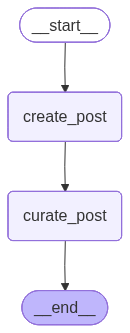

In [19]:
from IPython.display import Image, display
message_graph = graph.compile()

# You could see the errors with the below command
Image(message_graph.get_graph().draw_mermaid_png())

In [20]:
message_graph.invoke(
    {"message_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
     "message_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
)

{'message_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='In the digital age, where nearly every aspect of our lives is mediated by technology – from communication and commerce to healthcare and governance – data has become an invaluable asset, often referred to as the "new oil." Amidst this data deluge, the concept of **data privacy** has emerged not merely as a technical concern but as a fundamental human right and a cornerstone of a healthy digital society. Its importance cannot be overstated for individuals, businesses, and society as a whole.\n\n**What is Data Privacy?**\nData privacy refers to the right of individuals to control who can access, use, and share their personal information. It\'s not just about keeping data secret, but about having the power to decide how one\'s digital identity and personal details are handled by others, including companies, governments, and even ot